In [2]:
import os
import random

import pandas as pd
import numpy as np

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch import nn, optim
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from sklearn.metrics import log_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# Hyperparameter Setting
CFG = {
    'IMG_SIZE': 224,
    'BATCH_SIZE': 8,
    'EPOCHS': 10,
    'LEARNING_RATE': 1e-4,
    'SEED' : 42
}

In [4]:
# Fixed Random Seed
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['SEED']) # Seed 고정

In [5]:
# Custom Dataset
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_test=False):
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        self.samples = []

        if is_test:
            # 테스트셋: 라벨 없이 이미지 경로만 저장
            for fname in sorted(os.listdir(root_dir)):
                if fname.lower().endswith(('.jpg')):
                    img_path = os.path.join(root_dir, fname)
                    self.samples.append((img_path,))
        else:
            # 학습셋: 클래스별 폴더 구조에서 라벨 추출
            self.classes = sorted(os.listdir(root_dir))
            self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

            for cls_name in self.classes:
                cls_folder = os.path.join(root_dir, cls_name)
                for fname in os.listdir(cls_folder):
                    if fname.lower().endswith(('.jpg')):
                        img_path = os.path.join(cls_folder, fname)
                        label = self.class_to_idx[cls_name]
                        self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.is_test:
            img_path = self.samples[idx][0]
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image
        else:
            img_path, label = self.samples[idx]
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label

In [6]:
# Data Load
train_root = '../data/raw/train'
test_root = '../data/raw/test'

train_transform = transforms.Compose([
    transforms.Resize((CFG['IMG_SIZE'], CFG['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CFG['IMG_SIZE'], CFG['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 전체 데이터셋 로드
full_dataset = CustomImageDataset(train_root, transform=None)
print(f"총 이미지 수: {len(full_dataset)}")

targets = [label for _, label in full_dataset.samples]
class_names = full_dataset.classes

# Stratified Split
train_idx, val_idx = train_test_split(
    range(len(targets)), test_size=0.2, stratify=targets, random_state=42
)

# Subset + transform 각각 적용
train_dataset = Subset(CustomImageDataset(train_root, transform=train_transform), train_idx)
val_dataset = Subset(CustomImageDataset(train_root, transform=val_transform), val_idx)
print(f'train 이미지 수: {len(train_dataset)}, valid 이미지 수: {len(val_dataset)}')


# DataLoader 정의
train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=False)

총 이미지 수: 33137
train 이미지 수: 26509, valid 이미지 수: 6628


In [7]:
#Model Define

class BaseModel(nn.Module):
    def __init__(self, num_classes):
        super(BaseModel, self).__init__()
        self.backbone = models.efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
        self.feature_dim = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.head = nn.Linear(self.feature_dim, num_classes)

        # print("backbon : ", self.backbone)
    def forward(self, x):
        x = self.backbone(x)
        # print(f"backbone output: {x.shape}")
        x = self.head(x)
        return x

In [7]:
# Train / Validation

model = BaseModel(num_classes=len(class_names)).to(device)
print(f"model : {model}")
best_logloss = float('inf')

# 손실 함수
criterion = nn.CrossEntropyLoss()

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=CFG['LEARNING_RATE'])

# 학습 및 검증 루프
for epoch in range(CFG['EPOCHS']):
    # Train
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"[Epoch {epoch+1}/{CFG['EPOCHS']}] Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)  # logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"[Epoch {epoch+1}/{CFG['EPOCHS']}] Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # LogLoss
            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    val_logloss = log_loss(all_labels, all_probs, labels=list(range(len(class_names))))

    # 결과 출력
    print(f"Train Loss : {avg_train_loss:.4f} || Valid Loss : {avg_val_loss:.4f} | Valid Accuracy : {val_accuracy:.4f}%")

    # Best model 저장
    if val_logloss < best_logloss:
        best_logloss = val_logloss
        torch.save(model.state_dict(), f'../models/checkpoints/EfficientNet_B4_best_model.pth')
        print(f"📦 Best model saved at epoch {epoch+1} (logloss: {val_logloss:.4f})")

model : BaseModel(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
              (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
             

[Epoch 1/10] Validation: 100%|██████████| 829/829 [01:09<00:00, 11.94it/s]
/home/aimbelab/hai/ai/.pixi/envs/default/lib/python3.10/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Train Loss : 4.0386 || Valid Loss : 1.1059 | Valid Accuracy : 69.0857%
📦 Best model saved at epoch 1 (logloss: 1.1064)


[Epoch 2/10] Validation: 100%|██████████| 829/829 [01:04<00:00, 12.86it/s]
/home/aimbelab/hai/ai/.pixi/envs/default/lib/python3.10/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Train Loss : 0.9267 || Valid Loss : 0.4590 | Valid Accuracy : 85.3199%
📦 Best model saved at epoch 2 (logloss: 0.4592)


...

Train Loss : 0.0922 || Valid Loss : 0.2544 | Valid Accuracy : 93.0597%
📦 Best model saved at epoch 8 (logloss: 0.2545)


[Epoch 9/10] Validation: 100%|██████████| 829/829 [01:03<00:00, 12.96it/s]
/home/aimbelab/hai/ai/.pixi/envs/default/lib/python3.10/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Train Loss : 0.0729 || Valid Loss : 0.2638 | Valid Accuracy : 93.2710%


[Epoch 10/10] Validation: 100%|██████████| 829/829 [01:04<00:00, 12.94it/s]
/home/aimbelab/hai/ai/.pixi/envs/default/lib/python3.10/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Train Loss : 0.0573 || Valid Loss : 0.2526 | Valid Accuracy : 94.0253%
📦 Best model saved at epoch 10 (logloss: 0.2527)


In [8]:
# Inference

test_dataset = CustomImageDataset(test_root, transform=val_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=False)

# 저장된 모델 로드
model = BaseModel(num_classes=len(class_names))
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)

# 추론
model.eval()
results = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        # 각 배치의 확률을 리스트로 변환
        for prob in probs.cpu():  # prob: (num_classes,)
            result = {
                class_names[i]: prob[i].item()
                for i in range(len(class_names))
            }
            results.append(result)

pred = pd.DataFrame(results)

RuntimeError: Error(s) in loading state_dict for BaseModel:
	Missing key(s) in state_dict: "backbone.features.0.0.weight", "backbone.features.0.1.weight", "backbone.features.0.1.bias", "backbone.features.0.1.running_mean", "backbone.features.0.1.running_var", "backbone.features.1.0.block.0.0.weight", "backbone.features.1.0.block.0.1.weight", "backbone.features.1.0.block.0.1.bias", "backbone.features.1.0.block.0.1.running_mean", "backbone.features.1.0.block.0.1.running_var", "backbone.features.1.0.block.1.fc1.weight", "backbone.features.1.0.block.1.fc1.bias", "backbone.features.1.0.block.1.fc2.weight", "backbone.features.1.0.block.1.fc2.bias", "backbone.features.1.0.block.2.0.weight", "backbone.features.1.0.block.2.1.weight", "backbone.features.1.0.block.2.1.bias", "backbone.features.1.0.block.2.1.running_mean", "backbone.features.1.0.block.2.1.running_var", "backbone.features.1.1.block.0.0.weight", "backbone.features.1.1.block.0.1.weight", "backbone.features.1.1.block.0.1.bias", "backb

In [ ]:
# Submission

submission = pd.read_csv('../data/raw/sample_submission.csv', encoding='utf-8-sig')
import datetime
# 'ID' 컬럼을 제외한 클래스 컬럼 정렬
class_columns = submission.columns[1:]
pred = pred[class_columns]

model_name = model.backbone.__class__.__name__
date_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = "../outputs/submissions"

os.makedirs(save_dir, exist_ok=True)

submission[class_columns] = pred.values
submission.to_csv(f'{save_dir}/{model_name}_submission_{date_str}.csv', index=False, encoding='utf-8-sig')

NameError: name 'pd' is not defined

AttributeError: 'ConfusionMatrixDisplay' object has no attribute 'show'

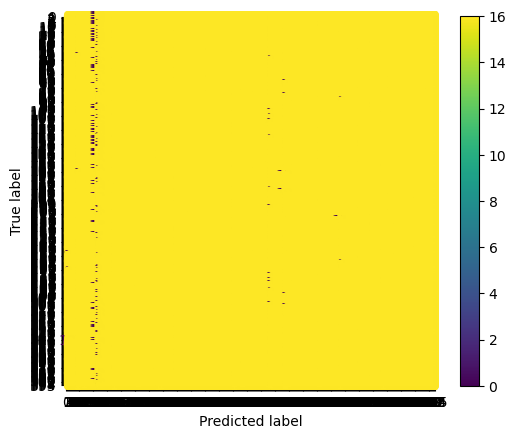

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model = model.to(device)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.show()
